In [ ]:
# Name : Shreyas Kurhekar
# Class : A-A2
# Roll : 32
# ML practical 5

In [14]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import (train_test_split,GridSearchCV,cross_val_score,StratifiedKFold)

from sklearn.preprocessing import StandardScaler

from sklearn.neighbors import KNeighborsClassifier

from sklearn.metrics import (accuracy_score,precision_score,recall_score,f1_score,confusion_matrix,classification_report)

import warnings
warnings.filterwarnings("ignore")
sns.set_theme(style="whitegrid")

In [2]:
df=pd.read_csv("diabetes.csv")

In [3]:
df.head()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
0,6,148,72,35,0,33.6,0.627,50,1
1,1,85,66,29,0,26.6,0.351,31,0
2,8,183,64,0,0,23.3,0.672,32,1
3,1,89,66,23,94,28.1,0.167,21,0
4,0,137,40,35,168,43.1,2.288,33,1


In [4]:
df.tail()

,Pregnancies,Glucose,BloodPressure,SkinThickness,Insulin,BMI,DiabetesPedigreeFunction,Age,Outcome
763,10,101,76,48,180,32.9,0.171,63,0
764,2,122,70,27,0,36.8,0.340,27,0
765,5,121,72,23,112,26.2,0.245,30,0
766,1,126,60,0,0,30.1,0.349,47,1
767,1,93,70,31,0,30.4,0.315,23,0


In [6]:
df.shape

(768, 9)

In [9]:
df.columns

Index(['Pregnancies', 'Glucose', 'BloodPressure', 'SkinThickness', 'Insulin',
       'BMI', 'DiabetesPedigreeFunction', 'Age', 'Outcome'],
      dtype='str')

In [10]:
df.dtypes

Pregnancies                   int64
Glucose                       int64
BloodPressure                 int64
SkinThickness                 int64
Insulin                       int64
BMI                         float64
DiabetesPedigreeFunction    float64
Age                           int64
Outcome                       int64
dtype: object

In [11]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 768 entries, 0 to 767
Data columns (total 9 columns):
 #   Column                    Non-Null Count  Dtype  
---  ------                    --------------  -----  
 0   Pregnancies               768 non-null    int64  
 1   Glucose                   768 non-null    int64  
 2   BloodPressure             768 non-null    int64  
 3   SkinThickness             768 non-null    int64  
 4   Insulin                   768 non-null    int64  
 5   BMI                       768 non-null    float64
 6   DiabetesPedigreeFunction  768 non-null    float64
 7   Age                       768 non-null    int64  
 8   Outcome                   768 non-null    int64  
dtypes: float64(2), int64(7)
memory usage: 54.1 KB


In [12]:
df.isnull().sum()

Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64

In [13]:
df.duplicated().sum()

np.int64(0)

In [15]:
# 1. Boxplot,Pie Chart
# 2. histogram
# 3. Count plot
# 4. scatter plot
# 5. heat map
# 6. pair plot

In [16]:
zero_columns=["Glucose","BloodPressure","SkinThickness","Insulin","BMI"]
zero_counts=(df[zero_columns]==0).sum()
print("Zero values:")
print(zero_counts)

Zero values:
Glucose            5
BloodPressure     35
SkinThickness    227
Insulin          374
BMI               11
dtype: int64


In [18]:
df_clean=df.copy()
df_clean[zero_columns]=df_clean[zero_columns].replace(0,np.nan)

print("Missing values after replacing invalid zeroes:")
print(df_clean.isnull().sum())

Missing values after replacing invalid zeroes:
Pregnancies                   0
Glucose                       5
BloodPressure                35
SkinThickness               227
Insulin                     374
BMI                          11
DiabetesPedigreeFunction      0
Age                           0
Outcome                       0
dtype: int64


In [19]:
for col in zero_columns:
    df_clean[col]=df_clean[col].fillna(df_clean[col].median())

print("Missing values after median imputaion")
print(df_clean.isnull().sum())

Missing values after median imputaion
Pregnancies                 0
Glucose                     0
BloodPressure               0
SkinThickness               0
Insulin                     0
BMI                         0
DiabetesPedigreeFunction    0
Age                         0
Outcome                     0
dtype: int64


In [20]:
X=df_clean.drop("Outcome",axis=1)
y=df_clean["Outcome"]
print("X shape: ",X.shape)
print("y shape: ",y.shape)

X shape:  (768, 8)
y shape:  (768,)


In [22]:
X_train,X_test,y_train,y_test=train_test_split(X,y,test_size=0.20,random_state=42,stratify=y)
print("Training Samples: ",X_train.shape[0])
print("Testing Samples: ",X_test.shape[0])

Training Samples:  614
Testing Samples:  154


In [23]:
print("Training Distribution:")
print(y_train.value_counts(normalize=True))

print("\nTesting Distribution:")
print(y_test.value_counts(normalize=True))

Training Distribution:
Outcome
0    0.651466
1    0.348534
Name: proportion, dtype: float64

Testing Distribution:
Outcome
0    0.649351
1    0.350649
Name: proportion, dtype: float64


In [24]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)

X_test_scaled = scaler.transform(X_test)

In [25]:
scaler.fit_transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]], shape=(154, 8))

In [26]:
scaler.transform(X_test)

array([[ 0.85252995,  1.16484536, -0.8288433 , ..., -0.71933141,
        -0.46562514,  0.63400979],
       [ 1.69054875, -1.66920722,  2.88630463, ...,  0.42561436,
        -0.49253293,  1.24533587],
       [-0.54416805,  0.01253827,  0.23262754, ...,  0.48215489,
         0.09943846, -0.58864236],
       ...,
       [-0.54416805, -1.23319913, -1.89031414, ..., -0.56384494,
         3.73497988, -0.67597466],
       [ 0.01451115,  1.94343123,  0.40953934, ...,  0.63764135,
        -0.55531777, -0.15198088],
       [-0.82350765, -1.57577692,  0.40953934, ...,  0.1005063 ,
        -0.08293657, -1.02530385]], shape=(154, 8))

In [27]:
comparison = pd.DataFrame({
    "Orignal Mean": X_train.mean(),
    "Orignal Std": X_train.std(),
    "Scaled Mean": X_train_scaled.mean(axis=0),
    "Scaled Std": X_train_scaled.std(axis=0)
})

display(comparison)

,Orignal Mean,Orignal Std,Scaled Mean,Scaled Std
Pregnancies,3.819218,3.314148,-6.943414e-17,1.0
Glucose,121.671010,30.003794,-1.099374e-16,1.0
BloodPressure,72.140065,12.275119,3.095606e-16,1.0
SkinThickness,29.042345,8.891855,-3.471707e-17,1.0
Insulin,137.705212,78.764767,-4.339634e-18,1.0
BMI,32.446743,6.824142,-1.148556e-15,1.0
DiabetesPedigreeFunction,0.477428,0.330300,-1.099374e-16,1.0
Age,33.366450,11.833438,-1.084908e-16,1.0


In [28]:
K=5

In [29]:
knn = KNeighborsClassifier(n_neighbors=5)
knn.fit(X_train_scaled,y_train)

,"n_neighbors n_neighbors: int, default=5Number of neighbors to use by default for :meth:`kneighbors` queries.",5
,"weights weights: {'uniform', 'distance'}, callable or None, default='uniform'Weight function used in prediction. Possible values:- 'uniform' : uniform weights. All points in each neighborhood are weighted equally.- 'distance' : weight points by the inverse of their distance. in this case, closer neighbors of a query point will have a greater influence than neighbors which are further away.- [callable] : a user-defined function which accepts an array of distances, and returns an array of the same shape containing the weights.Refer to the example entitled:ref:`sphx_glr_auto_examples_neighbors_plot_classification.py`showing the impact of the `weights` parameter on the decisionboundary.",'uniform'
,"algorithm algorithm: {'auto', 'ball_tree', 'kd_tree', 'brute'}, default='auto'Algorithm used to compute the nearest neighbors:- 'ball_tree' will use :class:`BallTree`- 'kd_tree' will use :class:`KDTree`- 'brute' will use a brute-force search.- 'auto' will attempt to decide the most appropriate algorithm based on the values passed to :meth:`fit` method.Note: fitting on sparse input will override the setting ofthis parameter, using brute force.",'auto'
,"leaf_size leaf_size: int, default=30Leaf size passed to BallTree or KDTree. This can affect thespeed of the construction and query, as well as the memoryrequired to store the tree. The optimal value depends on thenature of the problem.",30
,"p p: float, default=2Power parameter for the Minkowski metric. When p = 1, this is equivalentto using manhattan_distance (l1), and euclidean_distance (l2) for p = 2.For arbitrary p, minkowski_distance (l_p) is used. This parameter is expectedto be positive.",2
,"metric metric: str or callable, default='minkowski'Metric to use for distance computation. Default is ""minkowski"", whichresults in the standard Euclidean distance when p = 2. See thedocumentation of `scipy.spatial.distance<https://docs.scipy.org/doc/scipy/reference/spatial.distance.html>`_ andthe metrics listed in:class:`~sklearn.metrics.pairwise.distance_metrics` for valid metricvalues.If metric is ""precomputed"", X is assumed to be a distance matrix andmust be square during fit. X may be a :term:`sparse graph`, in whichcase only ""nonzero"" elements may be considered neighbors.If metric is a callable function, it takes two arrays representing 1Dvectors as inputs and must return one value indicating the distancebetween those vectors. This works for Scipy's metrics, but is lessefficient than passing the metric name as a string.",'minkowski'
,"metric_params metric_params: dict, default=NoneAdditional keyword arguments for the metric function.",None
,"n_jobs n_jobs: int, default=NoneThe number of parallel jobs to run for neighbors search.``None`` means 1 unless in a :obj:`joblib.parallel_backend` context.``-1`` means using all processors. See :term:`Glossary <n_jobs>`for more details.Doesn't affect :meth:`fit` method.",None
Name,Type,Value
"classes_ classes_: array of shape (n_classes,)Class labels known to the classifier","ndarray[int64](2,)","[0,1]"
"effective_metric_ effective_metric_: str or callbleThe distance metric used. It will be same as the `metric` parameteror a synonym of it, e.g. 'euclidean' if the `metric` parameter set to'minkowski' and `p` parameter set to 2.",str,'eu...an'


In [30]:
y_pred = knn.predict(X_test_scaled)
print("Predictions:")
print(y_pred[:20])

Predictions:
[1 0 0 1 0 0 0 1 0 1 0 1 0 0 0 1 1 0 1 0]


In [32]:
y_prob = knn.predict_proba(X_test_scaled)[:, 1]
print(y_prob[:20])

[0.6 0.2 0.2 0.6 0.  0.2 0.2 0.8 0.  0.6 0.4 0.6 0.  0.  0.  0.6 0.8 0.
 1.  0.2]


In [33]:
accuracy = accuracy_score(y_test,y_pred)
print(f"Accuracy: {accuracy:.4f}")

Accuracy: 0.7532


In [34]:
precision=precision_score(y_test,y_pred)
print(f"precision:{precision:.4f}")

precision:0.6600


In [35]:
recall=recall_score(y_test,y_pred)
print(f"recall:{recall:.4f}")

recall:0.6111


In [36]:
f1=f1_score(y_test,y_pred)
print(f"f1:{f1:.4f}")

f1:0.6346


In [37]:
print(classification_report(y_test,y_pred,target_names=["No Diabetes","Diabetes"]))

              precision    recall  f1-score   support

 No Diabetes       0.80      0.83      0.81       100
    Diabetes       0.66      0.61      0.63        54

    accuracy                           0.75       154
   macro avg       0.73      0.72      0.72       154
weighted avg       0.75      0.75      0.75       154



In [38]:
cm=confusion_matrix(y_test,y_pred)
print(cm)

[[83 17]
 [21 33]]


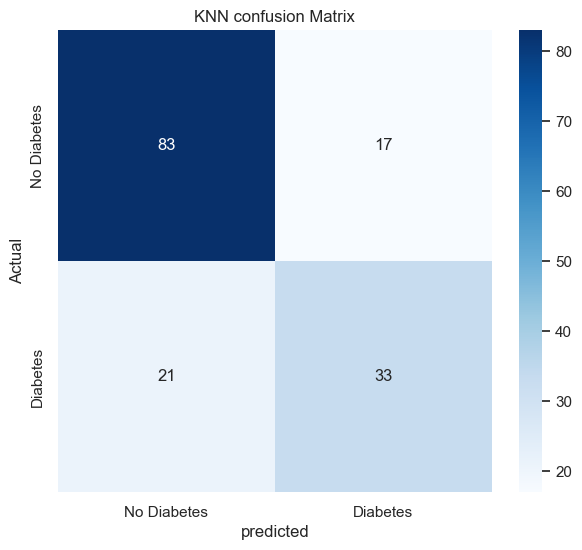

In [40]:
plt.figure(figsize=(7,6))

sns.heatmap(cm,annot=True,fmt="d",cmap="Blues",xticklabels=["No Diabetes","Diabetes"],yticklabels=["No Diabetes","Diabetes"])
plt.xlabel("predicted")
plt.ylabel("Actual")
plt.title("KNN confusion Matrix")
plt.show()

In [44]:
k_values=range(1,31)
train_accuracy=[]
test_accuracy=[]
for k in k_values:
    model=KNeighborsClassifier(n_neighbors=k)
    model.fit(X_train_scaled,y_train)
    train_accuracy.append(model.score(X_train_scaled,y_train))
    test_accuracy.append(model.score(X_test_scaled,y_test))

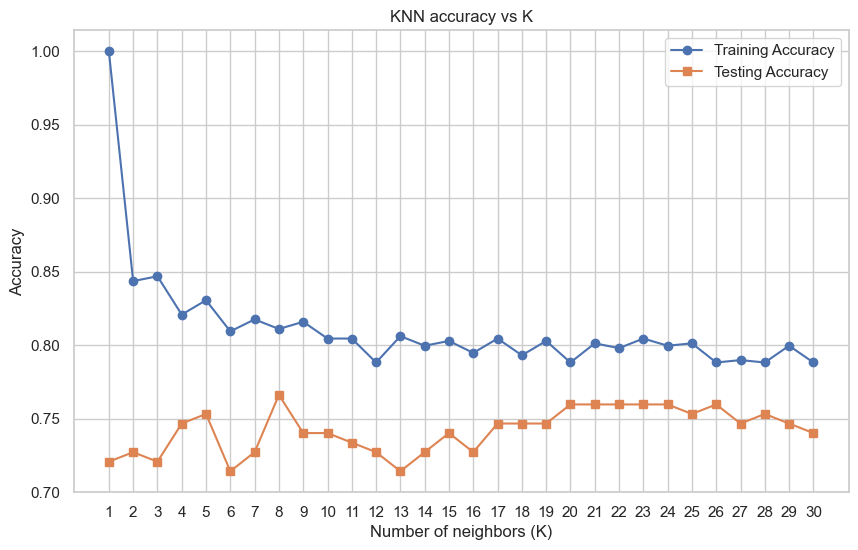

In [45]:
plt.figure(figsize=(10,6))
plt.plot(k_values,train_accuracy,marker="o",label="Training Accuracy")
plt.plot(k_values,test_accuracy,marker="s",label="Testing Accuracy")
plt.xlabel("Number of neighbors (K)")
plt.ylabel("Accuracy")
plt.title("KNN accuracy vs K")
plt.xticks(k_values)
plt.legend()
plt.show()

In [46]:
best_k_accuracy=k_values[np.argmax(test_accuracy)]
best_accuracy=max(test_accuracy)
print("Best k : ",best_k_accuracy)
print("Best test accuracy : ",best_accuracy)

Best k :  8
Best test accuracy :  0.7662337662337663


In [47]:
cv=StratifiedKFold(n_splits=5,shuffle=True,random_state=42)
cv_scores=[]
for k in range(1,31):
    model= KNeighborsClassifier(n_neighbors=k)
    scores=cross_val_score(model,X_train_scaled,y_train,cv=cv,scoring="accuracy")
    cv_scores.append(scores.mean())
    

In [48]:
best_k_cv=np.argmax(cv_scores)+1
print(" Best L based on cross validation: ",best_k_cv)
print(" Best CV accuracy :",max(cv_scores))

 Best L based on cross validation:  13
 Best CV accuracy : 0.7703718512594963


In [58]:
param_grid = {"n_neighbors": list(range(3,31,2)), "weights":["uniform","distance"], 
              "metric" : ["euclidean","manhattan","minkowski"],
             "p":[1,2]}

In [59]:
grid_search =GridSearchCV(estimator=KNeighborsClassifier(),param_grid=param_grid,cv=5,scoring="accuracy",n_jobs=-1)
grid_search.fit(X_train_scaled,y_train)
print("Grid search complted")

Grid search complted


In [60]:
print("Best Parameters:")
print(grid_search.best_params_)

Best Parameters:
{'metric': 'euclidean', 'n_neighbors': 19, 'p': 1, 'weights': 'uniform'}


In [61]:
print("Best Cross Validation Accuracy : ", grid_search.best_score_)

Best Cross Validation Accuracy :  0.7769025723044115


In [62]:
best_knn = grid_search.best_estimator_
print(best_knn)

KNeighborsClassifier(metric='euclidean', n_neighbors=19, p=1)


In [64]:
final_pred = best_knn.predict(X_test_scaled)
final_prob = best_knn.predict_proba(X_test_scaled)[:,1]